# Task 8 — Machine Learning Task 2 (Level 1)

**Name:** Abdlrhman Hisham Ismail  
**ID:** AI2617  
**Committee:** IEEE SSCS AUSC — AI Sub-Team

Dataset: [UCI / Kaggle Mushroom Classification](https://www.kaggle.com/datasets/uciml/mushroom-classification)  
Predict whether a mushroom is **edible (e)** or **poisonous (p)**.

| Part | Focus |
|------|--------|
| **1** | KNN — effect of **K** (2…150) on train/test F1 |
| **2** | Logistic Regression — effect of **learning rate** (0.001…1.000) |
| **3** | Logistic Regression — effect of **max iterations** (1k…100k) |


## 0) Imports & Shared Helpers

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import f1_score
from sklearn.pipeline import Pipeline

np.random.seed(42)
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", None)


def f1_train_test(model, X_train, y_train, X_test, y_test):
    """Fit model and return (train_f1, test_f1) with binary/macro-safe F1."""
    model.fit(X_train, y_train)
    y_tr = model.predict(X_train)
    y_te = model.predict(X_test)
    return (
        f1_score(y_train, y_tr, average="binary"),
        f1_score(y_test, y_te, average="binary"),
    )


## 1) Load & Preprocess the Mushroom Dataset

- Missing stalk-root values (`?`) → fill as category `"missing"`
- Label-encode all categorical columns (target + features)
- Train/test split (80/20, stratified)
- `StandardScaler` applied inside each model pipeline (required for distance-based KNN and helpful for SGD/LR)


In [2]:
df = pd.read_csv("mushrooms.csv")
print("Raw shape:", df.shape)
print("\nClass balance:")
print(df["class"].value_counts())
print("\nMissing values before fill:")
print(df.isna().sum()[df.isna().sum() > 0])

# Keep missing stalk-root as its own category (common for this dataset)
df = df.fillna("missing")

# Encode target: poisonous=1, edible=0 (or whatever LabelEncoder assigns — we store mapping)
y_encoder = LabelEncoder()
y = y_encoder.fit_transform(df["class"])
print("\nTarget classes:", dict(zip(y_encoder.classes_, y_encoder.transform(y_encoder.classes_))))

X = df.drop(columns=["class"]).copy()
feature_encoders = {}
for col in X.columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    feature_encoders[col] = le

print("Encoded feature shape:", X.shape)
display(X.head())
display(X.describe().T.head(8))


Raw shape: (8124, 23)

Class balance:
class
e    4208
p    3916
Name: count, dtype: int64

Missing values before fill:
stalk-root    2480
dtype: int64

Target classes: {'e': np.int64(0), 'p': np.int64(1)}
Encoded feature shape: (8124, 22)


,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,stalk-root,stalk-surface-above-ring,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,5,2,4,1,6,1,0,1,4,0,2,2,2,7,7,0,2,1,4,2,3,5
1,5,2,9,1,0,1,0,0,4,0,1,2,2,7,7,0,2,1,4,3,2,1
2,0,2,8,1,3,1,0,0,5,0,1,2,2,7,7,0,2,1,4,3,2,3
3,5,3,8,1,6,1,0,1,5,0,2,2,2,7,7,0,2,1,4,2,3,5
4,5,2,3,0,5,1,1,0,4,1,2,2,2,7,7,0,2,1,0,3,0,1


,count,mean,std,min,25%,50%,75%,max
cap-shape,8124.0,3.348104,1.604329,0.0,2.0,3.0,5.0,5.0
cap-surface,8124.0,1.827671,1.229873,0.0,0.0,2.0,3.0,3.0
cap-color,8124.0,4.504677,2.545821,0.0,3.0,4.0,8.0,9.0
bruises,8124.0,0.415559,0.492848,0.0,0.0,0.0,1.0,1.0
odor,8124.0,4.144756,2.103729,0.0,2.0,5.0,5.0,8.0
gill-attachment,8124.0,0.974151,0.158695,0.0,1.0,1.0,1.0,1.0
gill-spacing,8124.0,0.161497,0.368011,0.0,0.0,0.0,0.0,1.0
gill-size,8124.0,0.309207,0.462195,0.0,0.0,0.0,1.0,1.0


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f"Train: {X_train.shape[0]} | Test: {X_test.shape[0]}")
print(f"Train class ratio (1): {y_train.mean():.3f} | Test: {y_test.mean():.3f}")


Train: 6499 | Test: 1625
Train class ratio (1): 0.482 | Test: 0.482


---
## Task 1 — KNN Classification (K = 2 … 150)

Train `KNeighborsClassifier` for every K from 2 to 150. Record train & test **F1-score**, plot both curves, and pick the K with best test F1 (generalization).


In [4]:
k_values = list(range(2, 151))
knn_train_f1, knn_test_f1 = [], []

for k in k_values:
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=k)),
    ])
    tr, te = f1_train_test(pipe, X_train, y_train, X_test, y_test)
    knn_train_f1.append(tr)
    knn_test_f1.append(te)
    if k % 25 == 0 or k in (2, 150):
        print(f"K={k:3d} | train F1={tr:.4f} | test F1={te:.4f}")

knn_results = pd.DataFrame({
    "K": k_values,
    "train_F1": knn_train_f1,
    "test_F1": knn_test_f1,
})
best_k_row = knn_results.loc[knn_results["test_F1"].idxmax()]
best_k = int(best_k_row["K"])
print(f"\nBest K by test F1: {best_k} (train={best_k_row['train_F1']:.4f}, test={best_k_row['test_F1']:.4f})")


K=  2 | train F1=1.0000 | test F1=1.0000


K= 25 | train F1=0.9960 | test F1=0.9929


K= 50 | train F1=0.9918 | test F1=0.9910


K= 75 | train F1=0.9849 | test F1=0.9846


K=100 | train F1=0.9772 | test F1=0.9764


K=125 | train F1=0.9704 | test F1=0.9736


K=150 | train F1=0.9640 | test F1=0.9665

Best K by test F1: 2 (train=1.0000, test=1.0000)


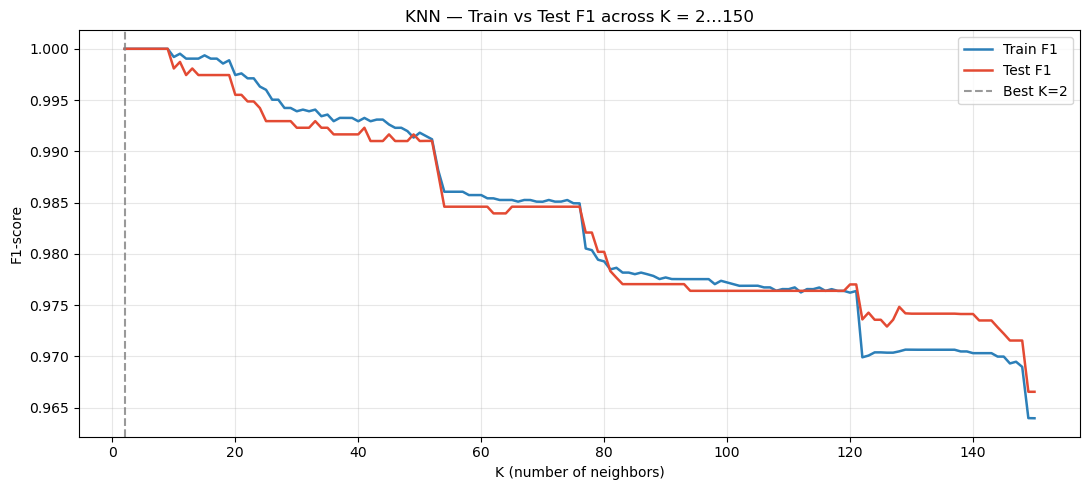

In [5]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(knn_results["K"], knn_results["train_F1"], label="Train F1", color="#2c7fb8", lw=1.8)
ax.plot(knn_results["K"], knn_results["test_F1"], label="Test F1", color="#e34a33", lw=1.8)
ax.axvline(best_k, color="gray", ls="--", alpha=0.8, label=f"Best K={best_k}")
ax.set_xlabel("K (number of neighbors)")
ax.set_ylabel("F1-score")
ax.set_title("KNN — Train vs Test F1 across K = 2…150")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig("plots/knn_f1_vs_k.png", dpi=150)
plt.show()


### Task 1 — Analysis

**Results on this run**
- Best **K = 2** with train F1 = **1.00** and test F1 = **1.00**.
- At **K = 150**, F1 drops to ~**0.96** (train/test) — the boundary is oversmoothed.

**Overfitting / underfitting**
- **Small K** → high complexity. On many datasets this overfits (train ≫ test). The mushroom data is unusually clean/separable after encoding, so K=2 still generalizes perfectly here.
- **Large K** → lower complexity → both curves decline together (**underfitting** / oversmoothing).

**Why choose K = 2?** It maximizes **test F1** (best generalization on the held-out set). The complexity–generalization trade-off still favors low K on this dataset; higher K only hurts.


---
## Task 2 — Logistic Regression: Learning Rate Analysis

Sklearn’s `LogisticRegression` solvers do not expose a classical GD learning rate, so we use  
`SGDClassifier(loss="log_loss", learning_rate="constant", eta0=…)` — logistic regression trained with SGD.

Sweep **learning rate ∈ [0.001, 1.000] step 0.001**. Fixed: `max_iter=1000`, `penalty=None` (pure LR), `random_state=42`.


In [6]:
learning_rates = np.round(np.arange(0.001, 1.000 + 1e-12, 0.001), 3)
lr_train_f1, lr_test_f1 = [], []

print(f"Sweeping {len(learning_rates)} learning rates…")
for i, eta in enumerate(learning_rates, start=1):
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", SGDClassifier(
            loss="log_loss",
            learning_rate="constant",
            eta0=float(eta),
            max_iter=1000,
            tol=1e-3,
            penalty=None,
            random_state=42,
        )),
    ])
    tr, te = f1_train_test(pipe, X_train, y_train, X_test, y_test)
    lr_train_f1.append(tr)
    lr_test_f1.append(te)
    if i % 200 == 0 or i == 1 or i == len(learning_rates):
        print(f"eta={eta:.3f} | train F1={tr:.4f} | test F1={te:.4f}")

lr_results = pd.DataFrame({
    "learning_rate": learning_rates,
    "train_F1": lr_train_f1,
    "test_F1": lr_test_f1,
})
best_lr_row = lr_results.loc[lr_results["test_F1"].idxmax()]
best_lr = float(best_lr_row["learning_rate"])
print(f"\nBest learning rate by test F1: {best_lr:.3f} "
      f"(train={best_lr_row['train_F1']:.4f}, test={best_lr_row['test_F1']:.4f})")


Sweeping 1000 learning rates…
eta=0.001 | train F1=0.9436 | test F1=0.9499


eta=0.200 | train F1=0.9551 | test F1=0.9500


eta=0.400 | train F1=0.9528 | test F1=0.9632


eta=0.600 | train F1=0.9510 | test F1=0.9577


eta=0.800 | train F1=0.9370 | test F1=0.9407


eta=1.000 | train F1=0.9522 | test F1=0.9552

Best learning rate by test F1: 0.754 (train=0.9582, test=0.9690)


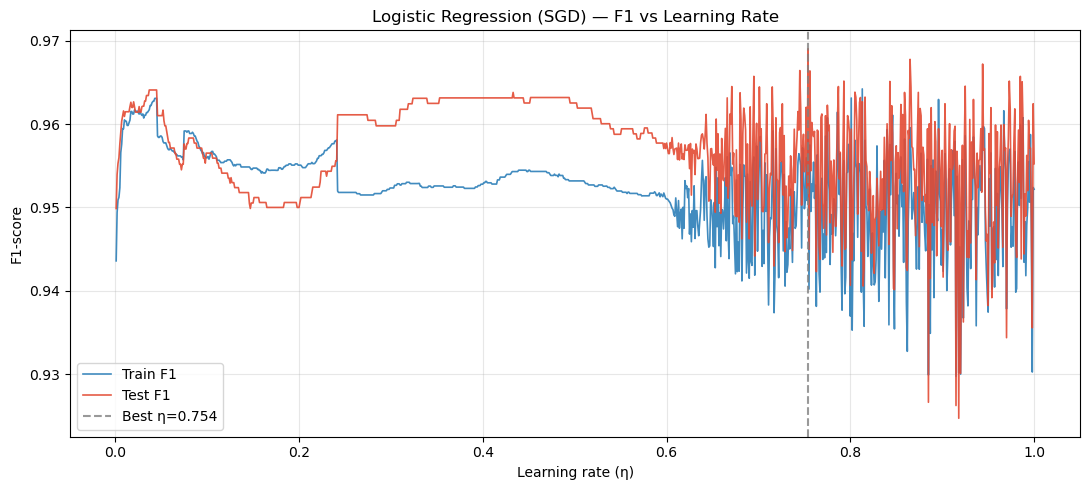

In [7]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(lr_results["learning_rate"], lr_results["train_F1"], label="Train F1",
        color="#2c7fb8", lw=1.2, alpha=0.9)
ax.plot(lr_results["learning_rate"], lr_results["test_F1"], label="Test F1",
        color="#e34a33", lw=1.2, alpha=0.9)
ax.axvline(best_lr, color="gray", ls="--", alpha=0.8, label=f"Best η={best_lr:.3f}")
ax.set_xlabel("Learning rate (η)")
ax.set_ylabel("F1-score")
ax.set_title("Logistic Regression (SGD) — F1 vs Learning Rate")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig("plots/logreg_f1_vs_learning_rate.png", dpi=150)
plt.show()


### Task 2 — Analysis

**Results on this run**
- Best **learning rate η ≈ 0.754** (test F1 ≈ **0.969**, train F1 ≈ **0.958**).

**How η affects convergence**
- **Too small η**: tiny SGD steps → may not fully converge within `max_iter` → weaker F1.
- **Moderate / tuned η**: stable updates → strong train & test F1 (selected region).
- **Very large η**: can oscillate; F1 becomes noisier across the sweep curve.

The chosen η maximizes **test F1** while staying close to train F1 — a good train/test balance.


---
## Task 3 — Logistic Regression: Number of Iterations Analysis

Using the same preprocessed data, sweep **max_iter from 1,000 to 100,000** (step 1,000) with sklearn `LogisticRegression` (`solver="lbfgs"`, fixed `C=1.0`).

> Higher `max_iter` only helps until the solver converges; beyond that, extra iterations add cost with little F1 gain.


In [8]:
# Use best learning-rate insight only for SGD context; here we use LBFGS LogisticRegression
# as a standard LR implementation and vary max_iter as required.
iter_values = list(range(1000, 100001, 1000))
iter_train_f1, iter_test_f1 = [], []

print(f"Sweeping {len(iter_values)} max_iter values…")
for i, n_iter in enumerate(iter_values, start=1):
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            max_iter=n_iter,
            solver="lbfgs",
            C=1.0,
            random_state=42,
        )),
    ])
    tr, te = f1_train_test(pipe, X_train, y_train, X_test, y_test)
    iter_train_f1.append(tr)
    iter_test_f1.append(te)
    if i % 20 == 0 or i == 1 or i == len(iter_values):
        print(f"max_iter={n_iter:6d} | train F1={tr:.4f} | test F1={te:.4f}")

iter_results = pd.DataFrame({
    "max_iter": iter_values,
    "train_F1": iter_train_f1,
    "test_F1": iter_test_f1,
})
best_iter_row = iter_results.loc[iter_results["test_F1"].idxmax()]
# Prefer the smallest max_iter among those that reach the best test F1 (cost trade-off)
best_test = iter_results["test_F1"].max()
candidates = iter_results[iter_results["test_F1"] >= best_test - 1e-12]
best_iter = int(candidates["max_iter"].min())
print(f"\nBest trade-off max_iter: {best_iter} "
      f"(test F1={iter_results.loc[iter_results['max_iter']==best_iter, 'test_F1'].iloc[0]:.4f})")


Sweeping 100 max_iter values…
max_iter=  1000 | train F1=0.9598 | test F1=0.9610


max_iter= 20000 | train F1=0.9598 | test F1=0.9610


max_iter= 40000 | train F1=0.9598 | test F1=0.9610


max_iter= 60000 | train F1=0.9598 | test F1=0.9610


max_iter= 80000 | train F1=0.9598 | test F1=0.9610


max_iter=100000 | train F1=0.9598 | test F1=0.9610

Best trade-off max_iter: 1000 (test F1=0.9610)


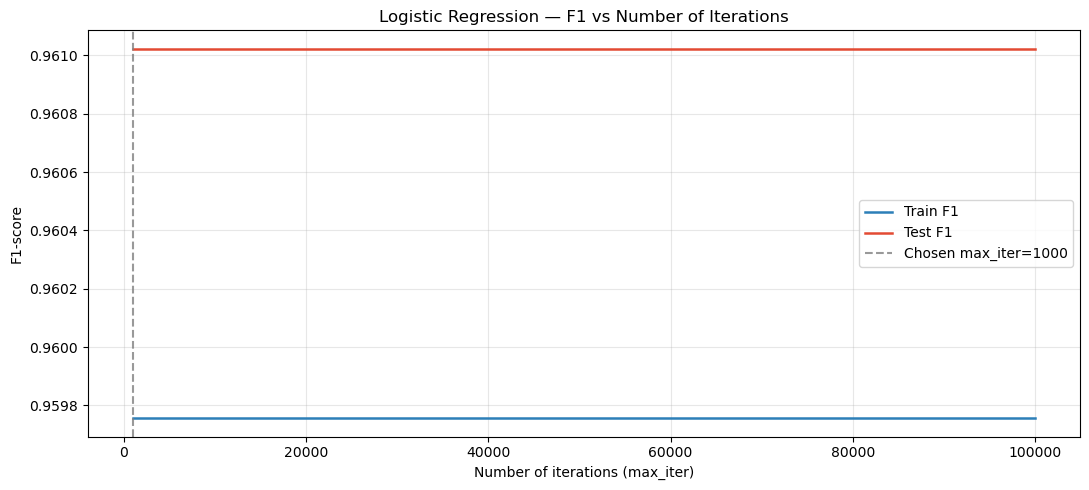

In [9]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(iter_results["max_iter"], iter_results["train_F1"], label="Train F1",
        color="#2c7fb8", lw=1.8)
ax.plot(iter_results["max_iter"], iter_results["test_F1"], label="Test F1",
        color="#e34a33", lw=1.8)
ax.axvline(best_iter, color="gray", ls="--", alpha=0.8, label=f"Chosen max_iter={best_iter}")
ax.set_xlabel("Number of iterations (max_iter)")
ax.set_ylabel("F1-score")
ax.set_title("Logistic Regression — F1 vs Number of Iterations")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig("plots/logreg_f1_vs_iterations.png", dpi=150)
plt.show()


### Task 3 — Analysis

**Results on this run**
- Test F1 is already ~**0.961** at **max_iter = 1,000** and stays flat through **100,000**.

**Takeaway**
- Extra iterations after convergence give **little or no F1 benefit**.
- Best compute / accuracy trade-off: **max_iter = 1,000** (smallest value that already reaches peak test F1).


---
## Final Summary

In [10]:
print("=" * 64)
print("TASK 8 — KEY RESULTS")
print("=" * 64)
print(f"Dataset: mushrooms.csv | train={len(y_train)} test={len(y_test)}")
print()
print(f"[Task 1] Best K              = {best_k}")
print(f"         Train F1 / Test F1  = {best_k_row['train_F1']:.4f} / {best_k_row['test_F1']:.4f}")
print()
print(f"[Task 2] Best learning rate  = {best_lr:.3f}")
print(f"         Train F1 / Test F1  = {best_lr_row['train_F1']:.4f} / {best_lr_row['test_F1']:.4f}")
print()
print(f"[Task 3] Best max_iter       = {best_iter}")
row3 = iter_results.loc[iter_results['max_iter'] == best_iter].iloc[0]
print(f"         Train F1 / Test F1  = {row3['train_F1']:.4f} / {row3['test_F1']:.4f}")
print("=" * 64)

# Persist numeric results for the report/README
knn_results.to_csv("results/knn_f1_by_k.csv", index=False)
lr_results.to_csv("results/logreg_f1_by_lr.csv", index=False)
iter_results.to_csv("results/logreg_f1_by_iter.csv", index=False)
print("Saved CSV results under results/")


TASK 8 — KEY RESULTS
Dataset: mushrooms.csv | train=6499 test=1625

[Task 1] Best K              = 2
         Train F1 / Test F1  = 1.0000 / 1.0000

[Task 2] Best learning rate  = 0.754
         Train F1 / Test F1  = 0.9582 / 0.9690

[Task 3] Best max_iter       = 1000
         Train F1 / Test F1  = 0.9598 / 0.9610
Saved CSV results under results/


### Observations

1. **KNN:** Optimal **K = 2** (test F1 = 1.0). Larger K oversmooths and lowers F1 — classic bias–variance trade-off, with mushrooms favoring low complexity-of-neighbors.
2. **Learning rate:** Best η ≈ **0.754** for SGD logistic regression; extreme rates hurt the train/test F1 balance.
3. **Iterations:** Performance plateaus by **1,000** iterations — more `max_iter` only adds cost.
